# TP Integrador Interpolación



In [1]:
# Librerias
import numpy as np
from pandas import read_csv 
import matplotlib.pyplot as plt

## Código para interpolar

In [24]:
class Interpolador_De_Newton():
    def __init__(self,X:np.ndarray, Y:np.ndarray, grado:int):
        self.X = X
        self.Y = Y
        self.grado = grado
        """Construir la matriz de diferencias finitas"""
        A = np.zeros(shape = (len(self.X), len(self.Y)))
        A[:,0] =self.Y # Primer columna es igual al vector de las ordenadas
        for j in range(1,self.grado+2):
            for i in range(0,(self.grado+1)-(j)):
                A[i,j] = (A[i+1,j-1] - A[i,j-1])/(self.X[i+j]-self.X[i])
        self.A = A

    def poly(self,x:float)->float:
        """Construye el polinomio y lo evalua"""
        # Polinomio interpolante
        yint = self.A[0,0]
        xterm = 1
        for i in range(1,self.grado+1):
            xterm = xterm * (x - self.X[i-1])
            yint = yint + self.A[0,i] * xterm
        return yint
    def str_poly(self):
        str_poly = f"{self.A[0,0]:.4f}"
        str_xterm = ""
        for i in range(1,self.grado+1):
            str_xterm = str_xterm + f" * (x - {self.X[i-1]})"
            str_poly = str_poly + f" + {self.A[0,i]:.4f} {str_xterm}"
        return str_poly

## Resolución

f0(x) = 0.0000 + 10.0000  * (x - -1.0)
f1(x) = 10.0000 + -0.0000  * (x - 0.0)
f2(x) = 10.0000 + 5.0000  * (x - -4.0)
f3(x) = 15.0000 + 0.0000  * (x - -3.0)
f4(x) = 15.0000 + 5.0000  * (x - 0.0) + -0.7475  * (x - 0.0) * (x - 1.0) + 0.0673  * (x - 0.0) * (x - 1.0) * (x - 5.5)
f5(x) = 25.0000 + -5.0000  * (x - 10.0)
f6(x) = 20.0000 + 0.5455  * (x - 11.0) + 0.0485  * (x - 11.0) * (x - 5.5) + 0.2081  * (x - 11.0) * (x - 5.5) * (x - 8.0)
f7(x) = 15.0000 + 0.0000  * (x - 5.0)
f8(x) = 15.0000 + 5.0000  * (x - 9.0)
f9(x) = 10.0000 + -0.0000  * (x - 8.0)
f10(x) = 10.0000 + 10.0000  * (x - 5.0)
f11(x) = 0.0000 + -0.0000  * (x - 4.0)
f12(x) = 0.0000 + -0.0667  * (x - 24.0) + 0.1022  * (x - 24.0) * (x - 22.5) + -0.0052  * (x - 24.0) * (x - 22.5) * (x - 15.0)
f13(x) = 7.5000 + 2.2500  * (x - 15.0) + -0.1742  * (x - 15.0) * (x - 17.0)
f14(x) = 15.0000 + 5.0000  * (x - 26.0)
f15(x) = 10.0000 + -0.3333  * (x - 25.0) + -0.4167  * (x - 25.0) * (x - 22.0)
f16(x) = 7.5000 + -1.7500  * (x - 20.0) + 0.4167  

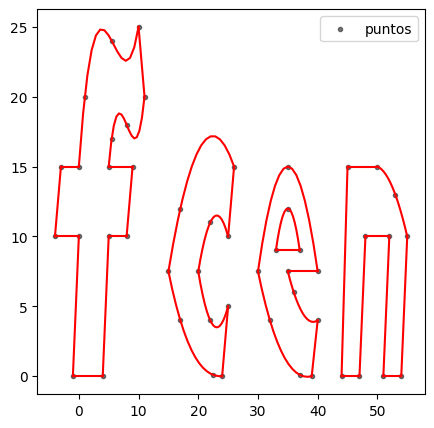

In [25]:
# Lectura de datos
puntos = read_csv("TPs/puntos.csv", sep=",", names = ["X", "Y"])
curvas = read_csv("TPs/curvas.csv", sep=",", names = ["P1", "P2", "P3", "P4"])
puntos.index = puntos.index + 1

# Esta funcion accede a la i-curvas y retorna una tupla con dos pares de listas ordenadas y abcisas
def asociar_curva_puntos(curva, puntos = puntos)->tuple[list]:
    px = []
    py = []
    for p in curva:
        if p == 0:
            continue
        px.append(puntos.loc[p]["X"])
        py.append(puntos.loc[p]["Y"]) 
    return (px, py)

# Interpola los puntos y retorna la curva interpolante con su dominio.
def interpolar_puntos(pxpy:tuple[list]) -> tuple:
    cant_puntos = len(pxpy[0])
    Interpolador = Interpolador_De_Newton(pxpy[0], pxpy[1], cant_puntos-1) 
    # Interpolación por polinomio interpolante de Newton
    poly = Interpolador.poly # Polinomio
    dominio = (min(pxpy[0]), max(pxpy[0]))
    str_poly = Interpolador.str_poly() # Polinomio forma literal
    return (poly, dominio, str_poly)

# Funcion main, recorre el dataframe curvas, curva por curva y genera el plot. 
def main():
    plt.figure(figsize=(5,5))
    for i in range(len(curvas)):
        curva = curvas.loc[i].values
        a = asociar_curva_puntos(curva)
        info_curva = interpolar_puntos(a)
        poly, dominio, str_poly = info_curva
        X = np.linspace(start=dominio[0], stop=dominio[1], num=15) # Genera 15 particiones del dominio
        Y = tuple(map(poly, X)) # Evalua 
        plt.plot(X, Y, color="red")
        print(f"f{i}(x) =",str_poly)
    plt.scatter(puntos["X"], puntos["Y"], color = "black", marker=".", alpha=0.5, label="puntos")
    plt.legend()
    plt.show()  
main()